TS4

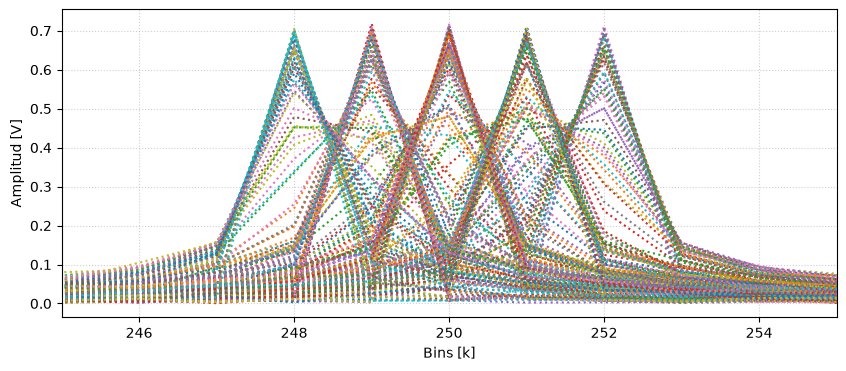

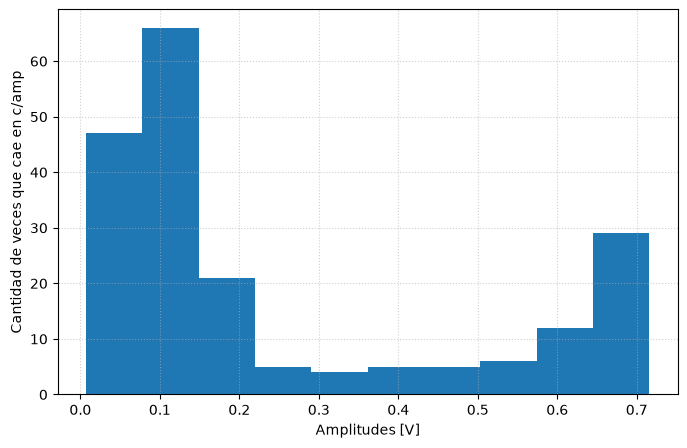

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sg

#fr*2pi*1/fs
#fila->tiempo;columna->repeticion

def graficador_histograma(xx):
    plt.figure(figsize=(8, 5))
    n_bins = 10
    counts, bins, _= plt.hist(xx, bins=n_bins)
    plt.xlabel("Amplitudes [V]")
    plt.ylabel("Cantidad de veces que cae en c/amp")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

snr_1=3#dB
snr_2=10#dB
ps=1#W Potencia de la señal
pr=ps*10**(-(snr_2/10))#potencia del ruido
a0=np.sqrt(2)
N=1000
nn=np.arange(0,N).reshape(N,1)#columna de 1000
R=200
fs=1000
df=fs/N
omega0=N//4
fr=np.random.uniform(-2,2,R).reshape(1,R) #fila de 200
na=np.random.normal(0,np.sqrt(pr),(N,R))
omega1=(omega0+fr)*df

#x(n)
xx=a0*np.sin(omega1*2*np.pi*nn/fs)+na #matriz de 1000;200

#transformada de xn normlizada
tr=(1/N)*np.fft.fft(xx,axis=0)# con axis le pide que haga la transformada por la columna

#%% Graficando el espectro total
modulo_tr_db = 10 * np.log10((np.abs(tr)) ** 2)
k=nn
fig=plt.figure(figsize=(10,4))
#plt.plot(k[:N//2], modulo_tr_db[:N//2],":")
plt.plot(k, np.abs(tr),":")
plt.xlabel("Bins [k]")
plt.ylabel("Amplitud [V]")
plt.xlim(245,255)
#plt.ylim(-30,0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
plt.close(fig)
#%%

#%%
flattop=sg.windows.flattop(N).reshape(N,1)
blackmanharris=sg.windows.blackmanharris(N).reshape(N,1)
triang=sg.windows.triang(N).reshape(N,1)


a1_rec=1/N*np.abs(np.fft.fft(xx,axis=0))[omega0,:].reshape(1,200)

a1_flattop=np.abs(np.fft.fft(xx*flattop))
a1_blackman=np.abs(np.fft.fft(xx*blackmanharris))
a1_triang=1/N*np.abs(np.fft.fft((xx*triang)))

#%%


# fig=plt.figure(figsize=(10,4))
# plt.plot(k[:N//2], a1_rec[:N//2],":", label = 'Rectuangular')
# plt.xlabel("Bins [k]")
# plt.ylabel("Amplitud [V]")
# #plt.xlim(245,255)
# #plt.ylim(-30,0)
# plt.legend(loc='upper right')
# plt.grid(True, linestyle=':', alpha=0.6)
# plt.show()
# plt.close(fig)
#%%
graficador_histograma(np.transpose(a1_rec))
#%%

#%%